In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [179]:
data = pd.read_csv('/content/insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [180]:
data.shape

(1338, 7)

In [181]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [182]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [183]:
data.drop_duplicates(inplace = True)
data.duplicated().sum()

np.int64(0)

In [184]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns
num_cols,cat_cols

(Index(['age', 'bmi', 'children', 'charges'], dtype='object'),
 Index(['sex', 'smoker', 'region'], dtype='object'))

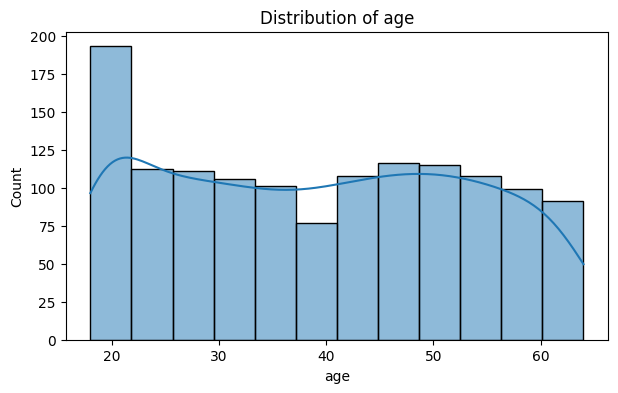

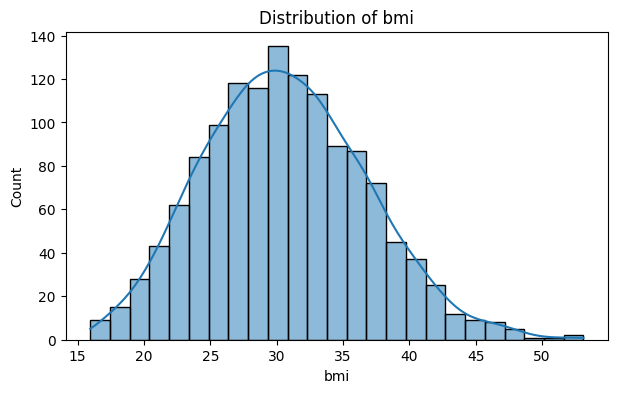

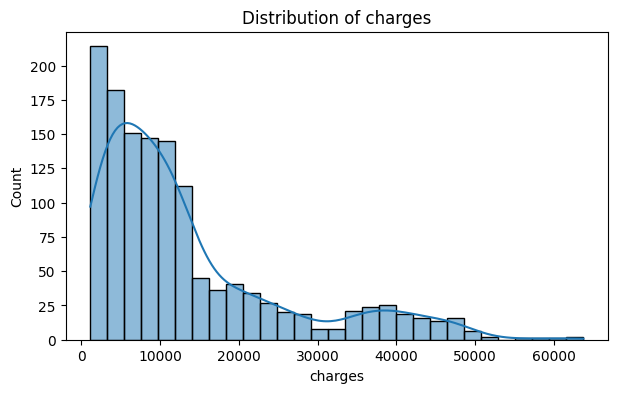

In [185]:
cols = ['age', 'bmi', 'charges']
for col in cols:
    plt.figure(figsize=(7,4))
    sns.histplot(x = data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

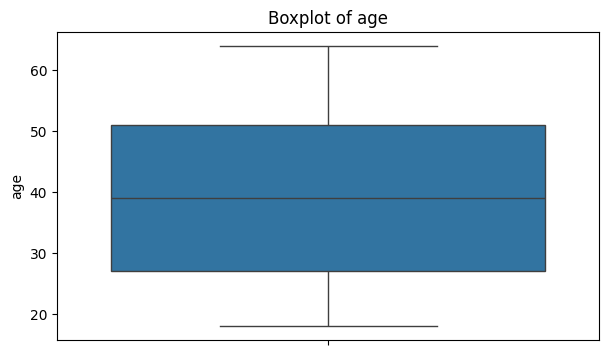

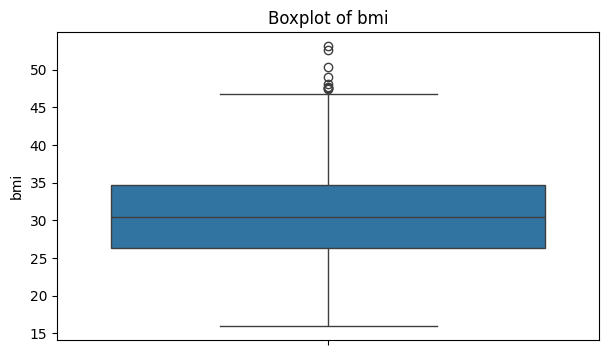

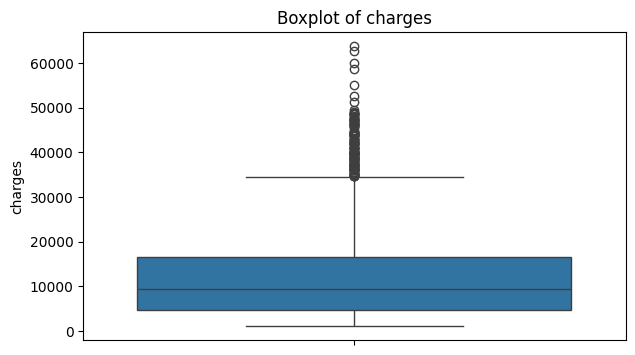

In [186]:
cols = ['age', 'bmi', 'charges']
for col in cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(y = data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [187]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])
    return df

for col in ['age', 'bmi', 'charges']:
    data = cap_outliers(data, col)

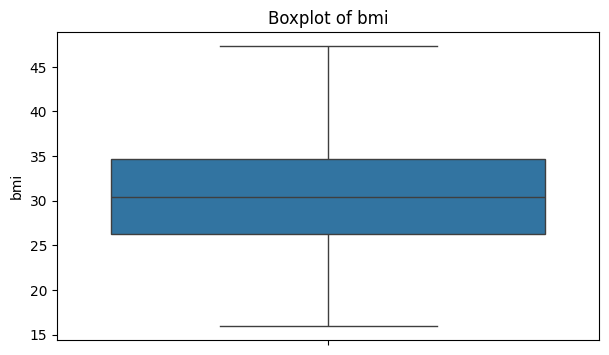

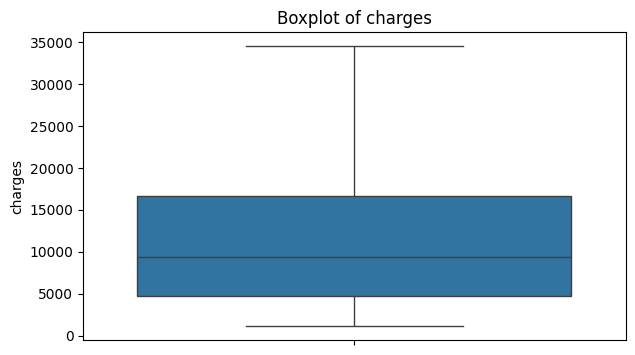

In [188]:
cols = ['age', 'bmi', 'charges']
for col in cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(y = data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

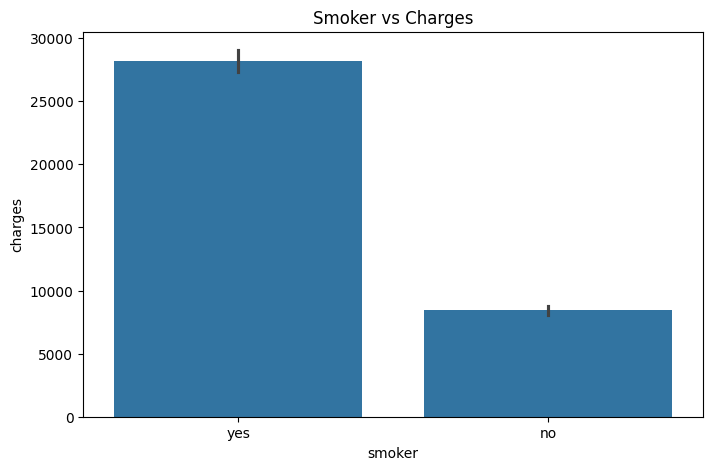

In [189]:
plt.figure(figsize=(8,5))
sns.barplot(x='smoker', y='charges', data=data)  # Y = 1, N = 0
plt.title('Smoker vs Charges')
plt.show()

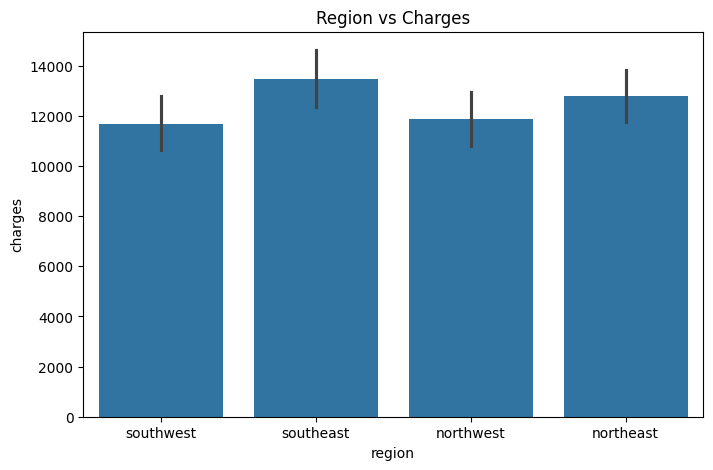

In [190]:
plt.figure(figsize=(8,5))
sns.barplot(x='region', y='charges', data=data) # 'southwest':0, 'southeast':1, 'northwest':2, 'northeast':3
plt.title('Region vs Charges')
plt.show()


In [191]:
data['sex'] = data['sex'].replace({'male':0, 'female':1})
data['smoker'] = data['smoker'].replace({'no':0, 'yes':1})
data['region'] = data['region'].replace({'southwest':0, 'southeast':1, 'northwest':2, 'northeast':3})
data

/tmp/ipykernel_6227/3918512569.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['sex'] = data['sex'].replace({'male':0, 'female':1})
/tmp/ipykernel_6227/3918512569.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['smoker'] = data['smoker'].replace({'no':0, 'yes':1})
/tmp/ipykernel_6227/3918512569.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,0,16884.92400
1,18,0,33.770,1,0,1,1725.55230
2,28,0,33.000,3,0,1,4449.46200
3,33,0,22.705,0,0,2,21984.47061
4,32,0,28.880,0,0,2,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,2,10600.54830
1334,18,1,31.920,0,0,3,2205.98080
1335,18,1,36.850,0,0,1,1629.83350
1336,21,1,25.800,0,0,0,2007.94500


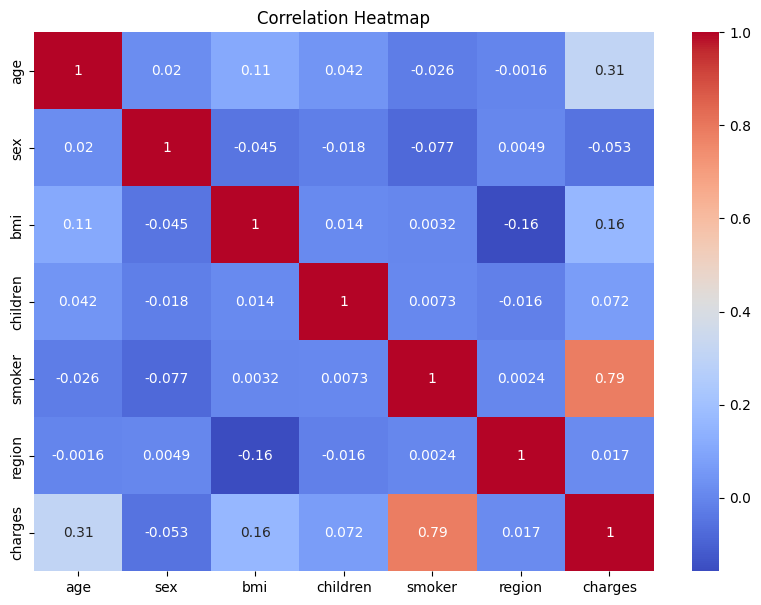

In [192]:
# heatmap
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [193]:
x = data.drop(['charges'], axis=1)
y = data['charges']

In [194]:
x

,age,sex,bmi,children,smoker,region
0,19,1,27.900,0,1,0
1,18,0,33.770,1,0,1
2,28,0,33.000,3,0,1
3,33,0,22.705,0,0,2
4,32,0,28.880,0,0,2
...,...,...,...,...,...,...
1333,50,0,30.970,3,0,2
1334,18,1,31.920,0,0,3
1335,18,1,36.850,0,0,1
1336,21,1,25.800,0,0,0


In [195]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [196]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [197]:
X_train, X_test, y_train, y_test

(      age  sex     bmi  children  smoker  region
 1114   23    0  24.510         0       0       3
 968    21    0  25.745         2       0       3
 599    52    1  37.525         2       0       2
 170    63    0  41.470         0       0       1
 275    47    1  26.600         2       0       3
 ...   ...  ...     ...       ...     ...     ...
 1096   51    1  34.960         2       1       3
 1131   27    0  45.900         2       0       0
 1295   20    0  22.000         1       0       0
 861    38    1  28.000         3       0       0
 1127   35    1  35.860         2       0       1
 
 [1069 rows x 6 columns],
       age  sex     bmi  children  smoker  region
 900    49    0  22.515         0       0       3
 1064   29    1  25.600         4       0       0
 1256   51    1  36.385         3       0       2
 298    31    0  34.390         3       1       2
 237    31    0  38.390         2       0       1
 ...   ...  ...     ...       ...     ...     ...
 534    64    0  40.48

In [201]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [199]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
pred = model.predict(X_test)
print("Model Performance:")
print("R2 Score: ", r2_score(y_test, pred))
print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))

Model Performance:
R2 Score:  0.8762959839572596
MAE:  2140.907851176598
MSE:  14455261.507883029


In [200]:
# create dataframe for new input
new_data = pd.DataFrame({
    'age': [28],
    'sex': [1],
    'bmi': [33.4],
    'children': [2],
    'smoker': [1],
    'region': [2]
})
result = model.predict(new_data)[0]
print(result)

34203.945
